In [ ]:
from analyzer import * 
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.set_theme(
    style="whitegrid",
    context="paper",
) 

vv = VQAResults()   
human_vqa = vv.human 
model_vqa = vv.model 

mm = MMStarResults()
model_mmstar = mm.model_blind  
human_mmstar = mm.human   
model_mmstar.finetuned.unique(), model_mmstar.condition.unique()  
 

In [12]:
model_vqa.finetuned.unique(), model_vqa.condition.unique()  
 

(array(['Pretrained', 'JS VQA (GT)', 'JS-Blind VQA (n=10)',
        'JS-Blind VQA (n=15)', 'JS-Blind MMStar (n=15)', 'SFT-Blind VQA',
        'SFT-VQA', 'SFT-Blind MMStar'], dtype=object),
 array(['inst blind'], dtype=object))

In [ ]:
df = pd.concat([model_mmstar, human_mmstar ]) 

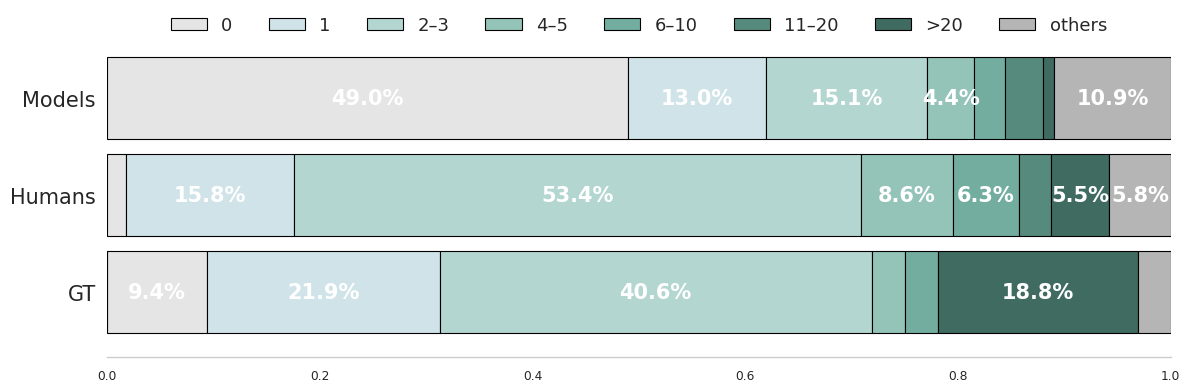

In [43]:
from utils.vqa import bin_number, yes_or_no, extract_number_or_other 

def filter_answer_type(df, answer_type, col):
    
    df = df[df['answer_type'] == answer_type].copy()
    df['output'] = df[col] 

    if answer_type == 'yes/no': 
        df = yes_or_no(df)
    else: 
        df = df[df['question_type'] != 'what time']
        df['output'] = df[col].apply(lambda x: pp.postprocess_answer(x.lower()))
        df['number'] = df['output'].apply(extract_number_or_other) 
        df['number_bin'] = df['number'].apply(bin_number) 

    return df 

pp = PostProcessor() 
h = filter_answer_type(human_vqa, 'number', 'answer_normalized')
m = filter_answer_type(model_vqa[model_vqa['finetuned'] == 'Pretrained' ], 'number', 'output') 
gt = filter_answer_type(model_vqa[model_vqa['finetuned'] == 'Pretrained' ], 'number', 'multiple_choice_answer')  

plot_df = pd.concat([
    gt[['number_bin']].assign(source='GT'),
    h[['number_bin']].assign(source='Humans'),
    m[['number_bin']].assign(source='Models')
])
counts = (
    plot_df
    .value_counts(['source', 'number_bin'])
    .reset_index(name='count')
)

counts['proportion'] = (
    counts
    .groupby('source')['count']
    .transform(lambda x: x / x.sum())
) 
stack_df = (
    counts
    .pivot(index='source', columns='number_bin', values='proportion')
    .fillna(0)
)
colors = {
    '0':     '#E5E5E5',
    '1':     '#CFE3E8',
    '2–3':   '#B3D6D1',
    '4–5':   '#94C3B8',
    '6–10':  '#73AD9F',
    '11–20': '#568A7D',
    '>20':   '#3F6B61',
    'others':'#B5B5B5'
}

order = ['0','1','2–3','4–5','6–10','11–20','>20','others'] 

fig, ax = plt.subplots(figsize=(12, 4))

stack_df[order].plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=[colors[c] for c in order],
    width=0.85,
    edgecolor='black',     # ✅ clear bar boundaries
    linewidth=0.8
)

ax.set_xlim(0, 1)
# ax.set_xlabel('Proportion')
ax.set_ylabel('')
ax.grid(False)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# percentage labels
for i, source in enumerate(stack_df.index):
    cum = 0
    for cat in order:
        val = stack_df.loc[source, cat]
        if val > 0.04:
            ax.text(
                cum + val / 2,
                i,
                f'{val*100:.1f}%',
                ha='center',
                va='center',
                color='white',
                fontsize=15,
                fontweight='bold'
            )
        cum += val
ax.tick_params(axis='y', labelsize=15)
ax.legend(
    bbox_to_anchor=(0.5, 1.1),
    loc='upper center',
    ncol=8,
    frameon=False, 
    fontsize=13
)

# plt.title('Numeric Answer Distribution (Binned & Normalized)')
plt.tight_layout()
plt.show()

In [ ]:

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "pdf.fonttype": 42,   # ✅ required for ACL (vector fonts)
    "ps.fonttype": 42
})

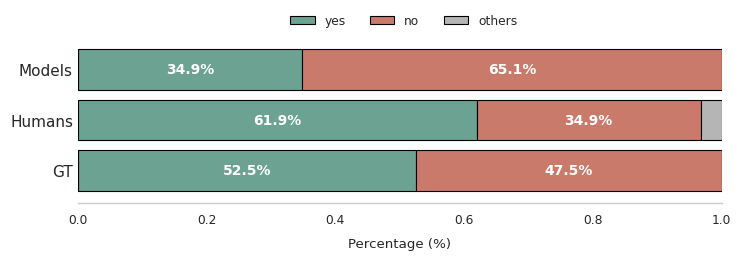

In [44]:
colors = {
    'yes': '#6BA292',     # muted teal
    'no': '#C97A6A',      # muted coral
    'others': '#B5B5B5'   # neutral gray
}

h = filter_answer_type(human_vqa, 'yes/no', 'answer_normalized')
m = filter_answer_type(model_vqa[model_vqa['finetuned'] == 'Pretrained' ], 'yes/no', 'output') 
gt = filter_answer_type(model_vqa[model_vqa['finetuned'] == 'Pretrained' ], 'yes/no', 'multiple_choice_answer')

plot_df = pd.concat([
    gt[['y/n']].assign(source='GT'),
    h[['y/n']].assign(source='Humans'),
    m[['y/n']].assign(source='Models')
]) 
counts = (
    plot_df
    .value_counts(['source', 'y/n'])
    .reset_index(name='count')
)

counts['proportion'] = (
    counts
    .groupby('source')['count']
    .transform(lambda x: x / x.sum())
)

stack_df = (
    counts
    .pivot(index='source', columns='y/n', values='proportion')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(7.5, 2.8))

stack_df[['yes', 'no', 'others']].plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=[colors[c] for c in ['yes', 'no', 'others']],
    width=0.8,   # ✅ thicker bars
    edgecolor='black',     # ✅ clear bar boundaries
    linewidth=0.8
)

# -----------------------
# Axis & grid styling
# -----------------------
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.yaxis.grid(False)

# --- Aesthetics ---
ax.set_xlim(0, 1)
# ax.set_xlabel('Proportion', fontsize=11)
ax.set_ylabel('')
ax.set_yticklabels(stack_df.index, fontsize=11)
ax.grid(False)

# Remove spines for clean look
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.0) 
ax.set_xlabel("Percentage (%)", labelpad=8)
ax.set_ylabel("")  # often cleaner in ACL figures

ax.tick_params(axis='x', length=4, width=1)
ax.tick_params(axis='y', length=0)

# --- Percentage labels inside bars ---
for i, source in enumerate(stack_df.index):
    cum = 0
    for cat in ['yes', 'no', 'others']:
        val = stack_df.loc[source, cat]
        if val > 0.04:  # avoid clutter on tiny segments
            ax.text(
                cum + val / 2,
                i,
                f'{val*100:.1f}%',
                ha='center',
                va='center',
                color='white',
                fontsize=10,
                fontweight='bold'
            )
        cum += val

# --- Legend outside, 2 columns ---
ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.7, 1.2),
    ncol=3,
    frameon=False
)

# plt.title('Yes / No Answer Distribution (Normalized)', fontsize=12)
plt.tight_layout()
plt.show()